# Example File for Final Project

This notebook provides an example to generate a TRISO cylindrical compact placed in an hexagonal graphite matrix.  The data provided does not match the geometry of the project so this should be used as a guide only.

In [1]:
%matplotlib inline
import openmc
import openmc.deplete
import matplotlib.pyplot as plt

In [2]:
openmc.config['cross_sections'] = '/home/ralitsam/endfb-vii.1-hdf5/cross_sections.xml'

In [3]:
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U238', 0.7502, 'wo')
fuel.add_nuclide('U235', 0.1376, 'wo')
fuel.add_nuclide('O16', 0.0897, 'wo')
fuel.add_nuclide('C0', 0.0224, 'wo')
fuel.set_density('g/cc', 10.5)

buff = openmc.Material(name='Buffer')
buff.add_nuclide('C0', 1.0, 'wo')
buff.set_density('g/cm3', 1.0)

iPyC = openmc.Material(name='iPyC')
iPyC.add_nuclide('C0', 1.0, 'wo')
iPyC.set_density('g/cm3', 1.9)

oPyC = openmc.Material(name='oPyC')
oPyC.add_nuclide('C0', 1.0, 'wo')
oPyC.set_density('g/cm3', 1.9)

SiC = openmc.Material(name='SiC')
SiC.add_nuclide('C0', 0.5, 'wo')
SiC.add_element('Si', 0.5, 'wo')
SiC.set_density('g/cm3', 3.2)

coolant = openmc.Material(name='coolant')
#FLiBe
coolant.add_nuclide('Li6', 0.0000707)
coolant.add_nuclide('Li7', 0.1413293)
coolant.add_nuclide('Be9',0.0909)
coolant.add_nuclide('F19',0.7677)
coolant.set_density('g/cm3',1.925)

In [4]:
graphite = openmc.Material(name='moderator')
graphite.add_nuclide('C0',  0.99998985, 'wo')
graphite.add_nuclide('B10', 0.00000015, 'wo')
graphite.add_nuclide('N14', 0.00001, 'wo')
graphite.set_density('g/cc', 1.6335)

In [5]:
materials_file = openmc.Materials([fuel, graphite, buff, iPyC, oPyC, SiC,coolant])
materials_file.export_to_xml()

In [6]:
fuel.temperature = 1000
buff.temperature = 900
iPyC.temperature = 900
oPyC.temperature = 900
SiC.temperature = 900
coolant.temperature = 900
graphite.temperature = 900

This block defines a fuel radius and a slightly smaller compact radius to avoid situations where TRISOs would be cut by the boundary.

In [7]:
top = openmc.ZPlane(surface_id=4, z0=+1, boundary_type='periodic')
bottom = openmc.ZPlane(surface_id=5, z0=-1, boundary_type='periodic') 

# Geometry definitions
fuel_radius = openmc.ZCylinder(surface_id=1, r=0.635) 
coolant_radius = openmc.ZCylinder(surface_id=2, r=0.35) 

compact_radius = openmc.ZCylinder(surface_id=6, r=0.635) 

top_compact = openmc.ZPlane(surface_id=7, z0=+0.999)
bottom_compact = openmc.ZPlane(surface_id=8, z0=-0.999) 

region = -compact_radius & -top_compact & +bottom_compact

fuel_region = -fuel_radius
moder_fuel = +fuel_radius
coolant_region = -coolant_radius 
moder_coolant = +coolant_radius 
 
fuel_cell = openmc.Cell(cell_id=1, fill=fuel, region=fuel_region)
moder_fuel_cell = openmc.Cell(cell_id=2, fill=graphite, region=moder_fuel)
graphite_cell = openmc.Cell(cell_id=3, fill=graphite)

coolant_cell = openmc.Cell(cell_id=4, fill=coolant, region=coolant_region)
moder_coolant_cell = openmc.Cell(cell_id=5, fill=graphite, region=moder_coolant)

This block creates a TRISO universe.

In [8]:
# Create TRISO universe
spheres = [openmc.Sphere(r=1e-4*r)
           for r in [212.5, 312.5, 347.5, 382.5]]
#spheres = [openmc.Sphere(r=r)
 #          for r in [0.02125, 0.03125, 0.03475, 0.03825]]
cells = [openmc.Cell(fill=fuel, region=-spheres[0]),
         openmc.Cell(fill=buff, region=+spheres[0] & -spheres[1]),
         openmc.Cell(fill=iPyC, region=+spheres[1] & -spheres[2]),
         openmc.Cell(fill=SiC, region=+spheres[2] & -spheres[3]),
         openmc.Cell(fill=oPyC, region=+spheres[3])]
triso_univ = openmc.Universe(cells=cells)

This block places spheres of a given size in a region with a user defined packing fraction.  As the packing fraction gets larger, the run time increases substantially.

In [9]:
outer_radius = 422.5*1e-4
#print(domain.volume)
centers = openmc.model.pack_spheres(radius=outer_radius, region=region, pf=0.35)

This block assigns a triso universe to each sphere.

In [10]:
trisos = [openmc.model.TRISO(outer_radius, triso_univ, center) for center in centers]

This block creates a lattice over the TRISO region for acceleration purposes.  A virtual mesh is added and a list of TRISOs in each mesh cell is calculated.  Thus, when in a given cell, the nearest neighbor search is limited to surfaces in the mesh.

In [11]:
lower_left, upper_right = fuel_cell.region.bounding_box
lower_left[2] = -1.0
upper_right[2] = 1.0
shape = (3, 3, 3)
pitch = (upper_right - lower_left)/shape
lattice = openmc.model.create_triso_lattice(
    trisos, lower_left, pitch, shape, graphite)

fuel_cell.fill = lattice

In [12]:
fuel_u = openmc.Universe(universe_id=1001, cells=(fuel_cell,moder_fuel_cell))
graphite_u = openmc.Universe(universe_id=1002, cells=[graphite_cell])
coolant_u = openmc.Universe(universe_id=1005, cells=[coolant_cell,moder_coolant_cell])

In [13]:
inner = [coolant_u]
outer = [coolant_u,fuel_u,coolant_u,fuel_u,coolant_u,fuel_u]

An hexagonal lattice is defined with a fuel universe surrounded by a graphite universe.

In [14]:
hex_lat = openmc.HexLattice(lattice_id=1003, name='assembly')
hex_lat.center = (0., 0.)
hex_lat.pitch = (1.8796,)
hex_lat.orientation = 'x'
hex_lat.outer = graphite_u
hex_lat.universes = [outer, inner]

An hexagonal bounding box is defined around the lattice.

In [15]:
# Create the prism that will contain the lattice
outer_surface = openmc.model.hexagonal_prism(edge_length=2.8194, orientation='x', boundary_type='periodic')

/home/ralitsam/.conda/envs/openmc-env/lib/python3.12/site-packages/openmc/model/funcs.py:124: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


In [16]:
# Fill a cell with the lattice. This cell is filled with the lattice and contained within the prism.
main_assembly = openmc.Cell(cell_id=7000, fill=hex_lat, region=outer_surface & -top & +bottom)

# Create a universe that contains both 
root = openmc.Universe(cells=[main_assembly])

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

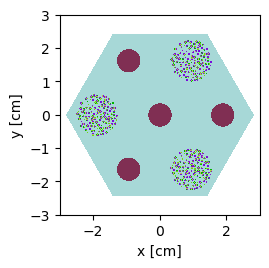

In [17]:
root.plot(origin = (0,0,0), pixels=(200, 200), width = (6.,6.), color_by = 'material')

In [18]:
geom = openmc.Geometry(root)
geom.export_to_xml()

In [19]:
# OpenMC simulation parameters

lower_left = [-3, -3, -1]
upper_right = [3, 3, 1]
uniform_dist = openmc.stats.Box(lower_left, upper_right)
src = openmc.IndependentSource(space=uniform_dist)#, constraints={'fissionable': True})

settings = openmc.Settings()
settings.source = src
settings.batches = 100
settings.inactive = 25
settings.particles = 2000
settings.temperature = {'method': 'interpolation','range':(293.15,1923.15)}

settings.export_to_xml()

In [20]:
%matplotlib inline
import openmc.examples
import numpy as np
import matplotlib.pyplot as plt

In [21]:
model = openmc.examples.pwr_pin_cell()

In [22]:
model.tallies

[]

In [23]:
# Create equal-lethargy energies to put in filter
energies = np.logspace(np.log10(1e-5), np.log10(20.0e6), 501)
e_filter = openmc.EnergyFilter(energies)

# Create tally with energy filter
tally = openmc.Tally()
tally.filters = [e_filter]
tally.scores = ['flux']

# Set model tallies
model.tallies = [tally]

In [24]:
openmc.mgxs.GROUP_STRUCTURES.keys()

dict_keys(['CASMO-2', 'CASMO-4', 'CASMO-8', 'CASMO-16', 'CASMO-25', 'CASMO-40', 'VITAMIN-J-42', 'SCALE-44', 'MPACT-51', 'MPACT-60', 'MPACT-69', 'CASMO-70', 'XMAS-172', 'VITAMIN-J-175', 'SCALE-252', 'TRIPOLI-315', 'SHEM-361', 'CCFE-709', 'UKAEA-1102', 'ECCO-1968'])

In [25]:
model.tallies

[Tally
 	ID             =	1
 	Name           =	
 	Filters        =	EnergyFilter
 	Nuclides       =	
 	Scores         =	['flux']
 	Estimator      =	None
 	Multiply dens. =	True]

In [26]:
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [27]:
fuel.volume = len(trisos)*4/3*3.1416*(212.5*1e-4)**3

In [ ]:
# Create depletion "operator"
model = openmc.Model(geometry=geom, materials=materials_file, settings=settings)
op = openmc.deplete.CoupledOperator(model, "chain_casl_pwr.xml")

# Perform simulation using the predictor algorithm
time_steps = [1.0, 2.0, 10.0, 20.0, 30.0]  # days
power = 1000  
integrator = openmc.deplete.PredictorIntegrator(op, time_steps, power, timestep_units='d')
integrator.integrate()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading Mo92 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Mo92.h5
 Reading Mo94 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Mo94.h5
 Reading Mo95 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Mo95.h5
 Reading Mo99 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Mo99.h5


 Reading Mo100 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Mo100.h5
 Reading Tc99 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Tc99.h5
 Reading Ru100 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ru100.h5
 Reading Ru101 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ru101.h5
 Reading Ru102 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ru102.h5
 Reading Ru103 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ru103.h5
 Reading Ru104 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ru104.h5
 Reading Ru105 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ru105.h5
 Reading Ru106 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ru106.h5
 Reading Rh103 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Rh103.h5
 Reading Rh105 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Rh105.h5
 Reading Pd104 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Pd104.h5
 Reading Pd105 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Pd105.h5
 Reading Pd106 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Pd106.h5
 Reading Pd107 from /home/ralitsam/e

 Reading I135 from /home/ralitsam/endfb-vii.1-hdf5/neutron/I135.h5
 Reading Xe128 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Xe128.h5
 Reading Xe130 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Xe130.h5
 Reading Xe131 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Xe131.h5
 Reading Xe132 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Xe132.h5
 Reading Xe133 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Xe133.h5


          2500K


 Reading Xe134 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Xe134.h5
 Reading Xe135 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Xe135.h5
 Reading Xe136 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Xe136.h5
 Reading Cs133 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Cs133.h5
 Reading Cs134 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Cs134.h5
 Reading Cs135 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Cs135.h5
 Reading Cs136 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Cs136.h5


          1200K
          2500K


 Reading Cs137 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Cs137.h5
 Reading Ba134 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ba134.h5
 Reading Ba137 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ba137.h5
 Reading Ba140 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ba140.h5
 Reading La139 from /home/ralitsam/endfb-vii.1-hdf5/neutron/La139.h5
 Reading La140 from /home/ralitsam/endfb-vii.1-hdf5/neutron/La140.h5
 Reading Ce140 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ce140.h5
 Reading Ce141 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ce141.h5
 Reading Ce142 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ce142.h5
 Reading Ce143 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ce143.h5
 Reading Ce144 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Ce144.h5
 Reading Pr141 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Pr141.h5
 Reading Pr142 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Pr142.h5
 Reading Pr143 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Pr143.h5
 Reading Nd142 from /home/ralitsam

          1200K
          2500K


 Reading Eu157 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Eu157.h5
 Reading Gd152 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Gd152.h5
 Reading Gd154 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Gd154.h5
 Reading Gd155 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Gd155.h5
 Reading Gd156 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Gd156.h5
 Reading Gd157 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Gd157.h5
 Reading Gd158 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Gd158.h5
 Reading Gd160 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Gd160.h5
 Reading Tb159 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Tb159.h5
 Reading Tb160 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Tb160.h5
 Reading Dy160 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Dy160.h5
 Reading Dy161 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Dy161.h5
 Reading Dy162 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Dy162.h5
 Reading Dy163 from /home/ralitsam/endfb-vii.1-hdf5/neutron/Dy163.h5
 Reading Dy164 from /home/ralitsam

In [ ]:
# Open results file
results = openmc.deplete.ResultsList.from_hdf5("depletion_results.h5")

# Obtain K_eff as a function of time
time, keff = results.get_eigenvalue()

# Obtain U235 concentration as a function of time
time, n_U235 = results.get_atoms('1', 'U235')

###############################################################################
#                            Generate plots
###############################################################################

days = 24*60*60
plt.figure()
plt.plot(time/days, keff[:,0], label="K-effective")
plt.xlabel("Time (days)")
plt.ylabel("Keff")
plt.show()

plt.figure()
plt.plot(time/days, n_U235, label="U235")
plt.xlabel("Time (days)")
plt.ylabel("n U5 (-)")
plt.show()


In [ ]:
print(results)

In [ ]:
with openmc.StatePoint(sp_path) as sp:
    t = sp.tallies[tally.id]
    flux500_mean = t.mean.ravel()
    flux500_unc = t.std_dev.ravel()